# Image Classification with Convolution Neural Network

In [1]:
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError
from tensorflow.keras.layers import BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix
import time
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1778255504.498751   28258 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
train_dir = "Dataset/train"
test_dir = "Dataset/test"
val_dir = "Dataset/val"

In [3]:
print(tf.config.list_physical_devices('GPU'))
# Expected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
print(tf.test.gpu_device_name())

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
/device:GPU:0


I0000 00:00:1778255515.091603   28258 gpu_device.cc:2043] Created device /device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [4]:
# Allow memory growth (allocates only what's needed)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

# Confirm GPU
print("GPU available:", len(gpus) > 0)

GPU available: True


In [5]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Data Understanding, Analysis, Visualization and Cleaning

In [7]:
# Get class names (subdirectories)
def get_class_names(directory):
  class_names = sorted(os.listdir(directory))
  if not class_names:
    print("No class directories found in the train folder!")
  else:
    print(f"Found {len(class_names)} classes: {class_names}")

In [8]:
def check_corrupt_images(directory):
  corrupted_images = [] # List to store corrupted images path
  # Loop through each class folder and check for corrupted images
  class_names = sorted(os.listdir(directory))
  for class_name in class_names:
    class_path = os.path.join(directory, class_name)
    if os.path.isdir(class_path): # Ensure it’s a valid directory
      images = os.listdir(class_path)
      for img_name in images:
        img_path = os.path.join(class_path, img_name)
        try:
          with Image.open(img_path) as img:
            img.verify() # Verify image integrity
        except (IOError, UnidentifiedImageError):
          corrupted_images.append(img_path)
  # Print results
  if corrupted_images:
    print("\nCorrupted Images Found in ",directory)
    for img in corrupted_images:
      print(img)
  else:
    print("\nNo corrupted images found in ", directory)

In [9]:
print("For train directory")
get_class_names(train_dir)

print("\nFor test directory")
get_class_names(test_dir)

print("\nFor val directory")
get_class_names(val_dir)


For train directory
Found 31 classes: ['Bangus', 'Big Head Carp', 'Black Spotted Barb', 'Catfish', 'Climbing Perch', 'Fourfinger Threadfin', 'Freshwater Eel', 'Glass Perchlet', 'Goby', 'Gold Fish', 'Gourami', 'Grass Carp', 'Green Spotted Puffer', 'Indian Carp', 'Indo-Pacific Tarpon', 'Jaguar Gapote', 'Janitor Fish', 'Knifefish', 'Long-Snouted Pipefish', 'Mosquito Fish', 'Mudfish', 'Mullet', 'Pangasius', 'Perch', 'Scat Fish', 'Silver Barb', 'Silver Carp', 'Silver Perch', 'Snakehead', 'Tenpounder', 'Tilapia']

For test directory
Found 31 classes: ['Bangus', 'Big Head Carp', 'Black Spotted Barb', 'Catfish', 'Climbing Perch', 'Fourfinger Threadfin', 'Freshwater Eel', 'Glass Perchlet', 'Goby', 'Gold Fish', 'Gourami', 'Grass Carp', 'Green Spotted Puffer', 'Indian Carp', 'Indo-Pacific Tarpon', 'Jaguar Gapote', 'Janitor Fish', 'Knifefish', 'Long-Snouted Pipefish', 'Mosquito Fish', 'Mudfish', 'Mullet', 'Pangasius', 'Perch', 'Scat Fish', 'Silver Barb', 'Silver Carp', 'Silver Perch', 'Snakehead',

In [30]:
check_corrupt_images(train_dir)
check_corrupt_images(test_dir)
check_corrupt_images(val_dir)


No corrupted images found in  Dataset/train

No corrupted images found in  Dataset/test

No corrupted images found in  Dataset/val


In [10]:
def count_class(directory):
  class_names = sorted(os.listdir(directory))
  class_counts = {}
  for class_name in class_names:
    class_path = os.path.join(directory, class_name)
    if os.path.isdir(class_path):
      images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg'
      , '.jpeg'))]
      class_counts[class_name] = len(images) # Count images in each class
  # Print Class Balance
  print("\nClass Distribution:")
  print("=" * 45)
  print(f"{'Class Name':<25}{'Valid Image Count':>15}")
  print("=" * 45)
  for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
  print("=" * 45)

In [11]:
print("Train directory")
count_class(train_dir)
print("\nTest directory")
count_class(test_dir)
print("\nVal directory")
count_class(val_dir)

Train directory

Class Distribution:
Class Name               Valid Image Count
Bangus                               171
Big Head Carp                        201
Black Spotted Barb                   200
Catfish                              314
Climbing Perch                       152
Fourfinger Threadfin                 191
Freshwater Eel                       271
Glass Perchlet                       397
Goby                                 607
Gold Fish                            206
Gourami                              311
Grass Carp                          1212
Green Spotted Puffer                 110
Indian Carp                          262
Indo-Pacific Tarpon                  186
Jaguar Gapote                        229
Janitor Fish                         286
Knifefish                            319
Long-Snouted Pipefish                256
Mosquito Fish                        254
Mudfish                              189
Mullet                               174
Pangasius         

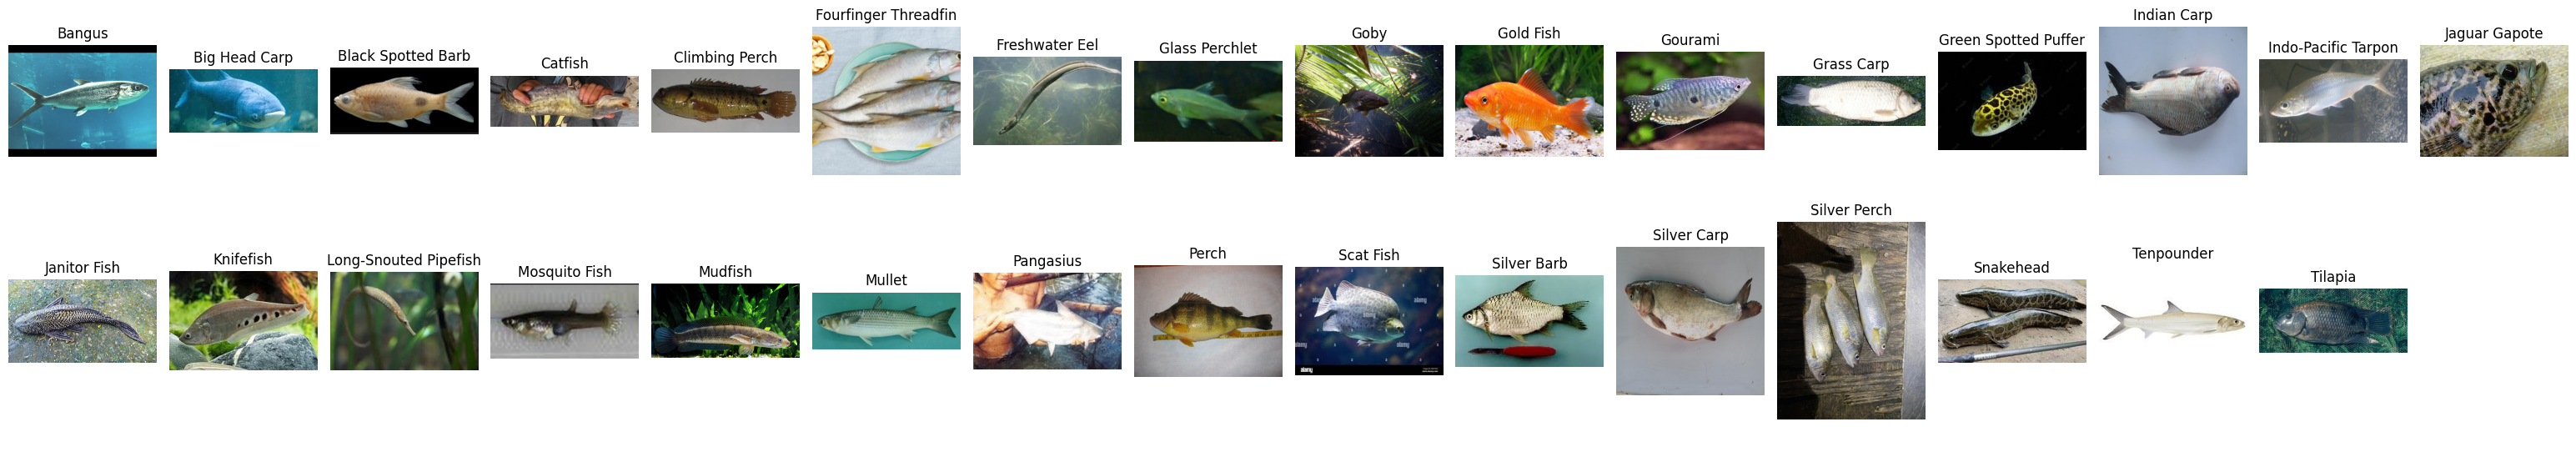

In [12]:
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
class_names = sorted(os.listdir(train_dir))
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg'
    , '.jpeg'))]
    if images: # Ensure the class folder is not empty
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(31, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

# Part A: Designing and Analyzing Convolutional Neural Networks from Scratch.

In [6]:
img_height = 224
img_width = 224
batch_size = 16

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=True,
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=False,
    seed=123
)

num_classes = len(train_ds.class_names)
class_names = train_ds.class_names

Found 8809 files belonging to 31 classes.


I0000 00:00:1778255541.564534   28258 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 2751 files belonging to 31 classes.


In [7]:
from sklearn.utils.class_weight import compute_class_weight

all_labels = np.concatenate([y.numpy() for x, y in train_ds])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)

class_weights_dict = dict(enumerate(class_weights))

In [15]:
baseline_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),         # Only normalization here

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 31)             │         1,023 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,949,791 (49.40 MB)

 Trainable params: 12,949,791 (49.40 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [18]:
start_time = time.time()
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    batch_size=16,
    callbacks=[early_stop],
    class_weight = class_weights_dict
)
baseline_train_time = time.time() - start_time

Epoch 1/30


I0000 00:00:1778241963.476903    1142 service.cc:153] XLA service 0x789364035fb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778241963.476988    1142 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778241963.596806    1142 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778241965.304407    1142 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778241965.382682    1142 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4264__.61


  7/551 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.0239 - loss: 3.4013

I0000 00:00:1778241995.240443    1142 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


549/551 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0478 - loss: 3.3946

I0000 00:00:1778242013.956162    1144 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4264__.61


551/551 ━━━━━━━━━━━━━━━━━━━━ 91s 102ms/step - accuracy: 0.0834 - loss: 3.2355 - val_accuracy: 0.1585 - val_loss: 2.8840
Epoch 2/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.2362 - loss: 2.6025 - val_accuracy: 0.3417 - val_loss: 2.2961
Epoch 3/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - accuracy: 0.3941 - loss: 2.0217 - val_accuracy: 0.5147 - val_loss: 1.7321
Epoch 4/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.5776 - loss: 1.3810 - val_accuracy: 0.6638 - val_loss: 1.1811
Epoch 5/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.7115 - loss: 0.8962 - val_accuracy: 0.7623 - val_loss: 0.8808
Epoch 6/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.8101 - loss: 0.5828 - val_accuracy: 0.8088 - val_loss: 0.7619
Epoch 7/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.8695 - loss: 0.3943 - val_accuracy: 0.8550 - val_loss: 0.6312
Epoch 8/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9051 - loss: 0.2985 - val_accura

In [19]:
print(f"Baseline training time: {baseline_train_time:.2f} seconds")

Baseline training time: 701.37 seconds


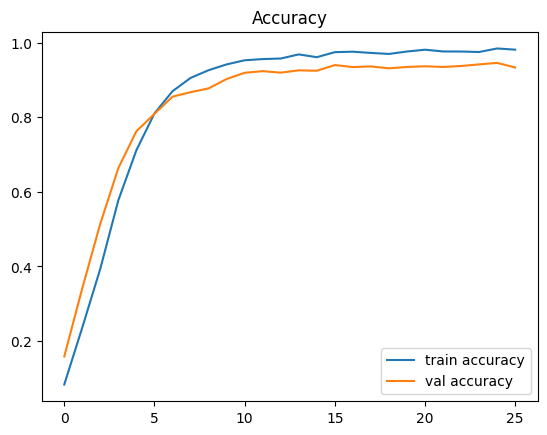

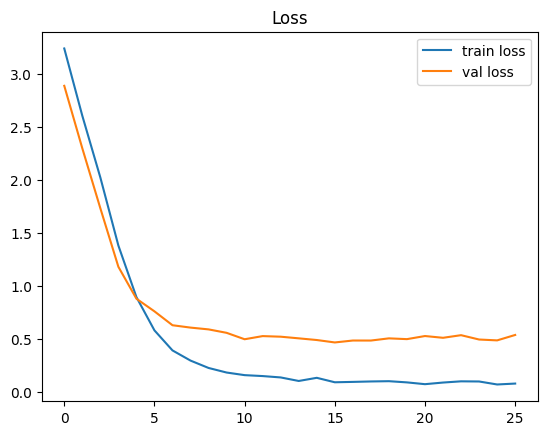

In [20]:
# Accuracy
plt.plot(baseline_history.history['accuracy'], label='train accuracy')
plt.plot(baseline_history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(baseline_history.history['loss'], label='train loss')
plt.plot(baseline_history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [8]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 1761 files belonging to 31 classes.


In [22]:
# Get predictions (probabilities)
y_pred_probs = baseline_model.predict(test_ds)
# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)
# Get true labels from the dataset
# Since shuffle=False, these will match the order of predictions
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_ds.class_names))

56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step

Classification Report:
                       precision    recall  f1-score   support

               Bangus       0.93      0.82      0.88        34
        Big Head Carp       0.69      0.84      0.76        43
   Black Spotted Barb       0.77      0.82      0.80        40
              Catfish       0.85      0.89      0.87        62
       Climbing Perch       0.83      0.80      0.81        30
 Fourfinger Threadfin       0.81      0.92      0.86        38
       Freshwater Eel       0.89      0.87      0.88        55
       Glass Perchlet       0.85      0.92      0.88        77
                 Goby       0.90      0.89      0.89       124
            Gold Fish       0.98      0.98      0.98        41
              Gourami       0.85      0.95      0.90        63
           Grass Carp       0.93      0.93      0.93       238
 Green Spotted Puffer       1.00      0.82      0.90        22
          Indian Carp       0.87      0.89      0.8

# Deeper Architecture with Regularization

In [8]:
deeper_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),         # Only normalization here

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    
    # Block 4
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 5
    layers.Conv2D(512, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 6
    layers.Conv2D(1024, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
deeper_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,734,495 (25.69 MB)

 Trainable params: 6,730,463 (25.67 MB)

 Non-trainable params: 4,032 (15.75 KB)

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

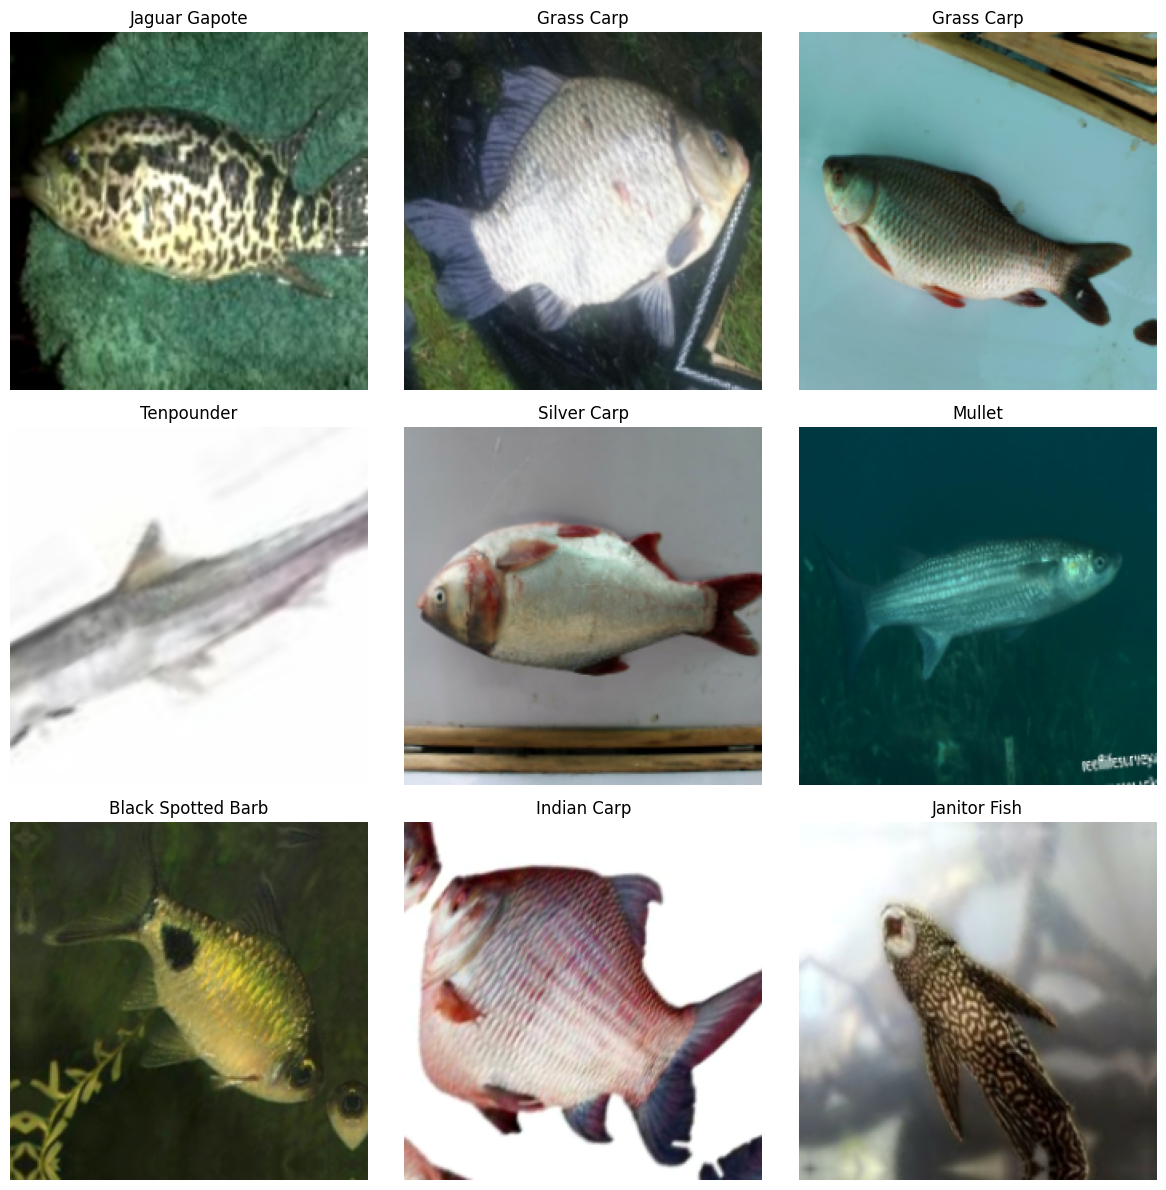

In [10]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 12))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [11]:
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
deeper_start_time = time.time()
deeper_history = deeper_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    class_weight = class_weights_dict
)
deeper_train_time = time.time() - deeper_start_time

Epoch 1/50


I0000 00:00:1778252732.714133   22167 service.cc:153] XLA service 0x71a288044ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778252732.714271   22167 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778252733.132451   22167 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778252736.833969   22167 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778252737.195778   22167 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10138__.153
I0000 00:00:1778252787.651889   22167 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


549/551 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0592 - loss: 3.4127

I0000 00:00:1778252816.035890   22168 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10138__.153


551/551 ━━━━━━━━━━━━━━━━━━━━ 152s 160ms/step - accuracy: 0.0707 - loss: 3.3509 - val_accuracy: 0.1036 - val_loss: 3.0974
Epoch 2/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1253 - loss: 3.1019 - val_accuracy: 0.1425 - val_loss: 3.1167
Epoch 3/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 36s 64ms/step - accuracy: 0.1492 - loss: 2.9354 - val_accuracy: 0.1850 - val_loss: 2.8960
Epoch 4/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.1721 - loss: 2.8294 - val_accuracy: 0.1981 - val_loss: 2.8643
Epoch 5/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.2124 - loss: 2.6915 - val_accuracy: 0.2443 - val_loss: 2.7227
Epoch 6/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.2409 - loss: 2.5792 - val_accuracy: 0.3279 - val_loss: 2.3262
Epoch 7/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.2740 - loss: 2.4802 - val_accuracy: 0.3442 - val_loss: 2.2865
Epoch 8/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.3084 - loss: 2.3745 - val_accur

Deeper training time: 1817.32 seconds


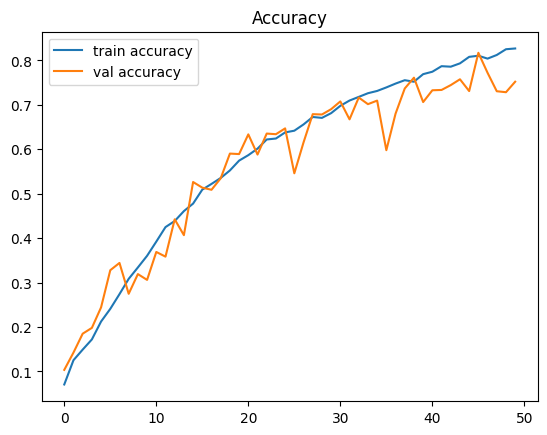

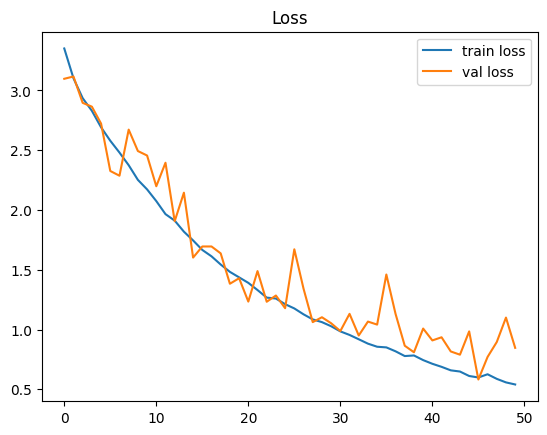

In [15]:
print(f"Deeper training time: {deeper_train_time:.2f} seconds")
# Accuracy
plt.plot(deeper_history.history['accuracy'], label='train accuracy')
plt.plot(deeper_history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(deeper_history.history['loss'], label='train loss')
plt.plot(deeper_history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [17]:
# Get predictions (probabilities)
y_pred_probs = deeper_model.predict(test_ds)
# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)
# Get true labels from the dataset
# Since shuffle=False, these will match the order of predictions
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_ds.class_names))

56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 142ms/step

Classification Report:
                       precision    recall  f1-score   support

               Bangus       0.45      0.82      0.58        34
        Big Head Carp       0.94      0.70      0.80        43
   Black Spotted Barb       0.92      0.82      0.87        40
              Catfish       0.79      0.71      0.75        62
       Climbing Perch       0.90      0.63      0.75        30
 Fourfinger Threadfin       0.71      0.92      0.80        38
       Freshwater Eel       0.55      0.78      0.65        55
       Glass Perchlet       0.95      0.91      0.93        77
                 Goby       0.79      0.82      0.81       124
            Gold Fish       1.00      1.00      1.00        41
              Gourami       0.92      0.97      0.95        63
           Grass Carp       0.99      0.87      0.92       238
 Green Spotted Puffer       0.95      0.95      0.95        22
          Indian Carp       0.80      1.00      0.8

# With SGD

In [11]:
#With SGD optimizer
deeper_model_sgd = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),         # Only normalization here

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    
    # Block 4
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 5
    layers.Conv2D(512, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 6
    layers.Conv2D(1024, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
deeper_model_sgd.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,734,495 (25.69 MB)

 Trainable params: 6,730,463 (25.67 MB)

 Non-trainable params: 4,032 (15.75 KB)

In [12]:
deeper_model_sgd.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deeper_start_time_withsgd = time.time()
deeper_history = deeper_model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    class_weight = class_weights_dict
)
baseline_train_time = time.time() - deeper_start_time_withsgd

Epoch 1/50


I0000 00:00:1778255714.784061   28383 service.cc:153] XLA service 0x781dd8036560 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778255714.784176   28383 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778255715.016480   28383 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778255716.868161   28383 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778255717.207013   28383 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5416__.153
I0000 00:00:1778255764.830976   28383 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


549/551 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0397 - loss: 3.4186

I0000 00:00:1778255792.780482   28384 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5416__.153


551/551 ━━━━━━━━━━━━━━━━━━━━ 141s 158ms/step - accuracy: 0.0557 - loss: 3.3877 - val_accuracy: 0.0825 - val_loss: 3.2932
Epoch 2/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 32s 57ms/step - accuracy: 0.1179 - loss: 3.1460 - val_accuracy: 0.1283 - val_loss: 3.2906
Epoch 3/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.1477 - loss: 2.9173 - val_accuracy: 0.1559 - val_loss: 2.9281
Epoch 4/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 33s 59ms/step - accuracy: 0.1799 - loss: 2.7494 - val_accuracy: 0.1330 - val_loss: 2.9245
Epoch 5/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 33s 59ms/step - accuracy: 0.2082 - loss: 2.6344 - val_accuracy: 0.2305 - val_loss: 2.4968
Epoch 6/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 36s 64ms/step - accuracy: 0.2401 - loss: 2.5508 - val_accuracy: 0.2225 - val_loss: 2.6861
Epoch 7/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 37s 66ms/step - accuracy: 0.2749 - loss: 2.4556 - val_accuracy: 0.2337 - val_loss: 2.7401
Epoch 8/50
551/551 ━━━━━━━━━━━━━━━━━━━━ 36s 64ms/step - accuracy: 0.2915 - loss: 2.3815 - val_accur

Deeper training time: 1859.08 seconds


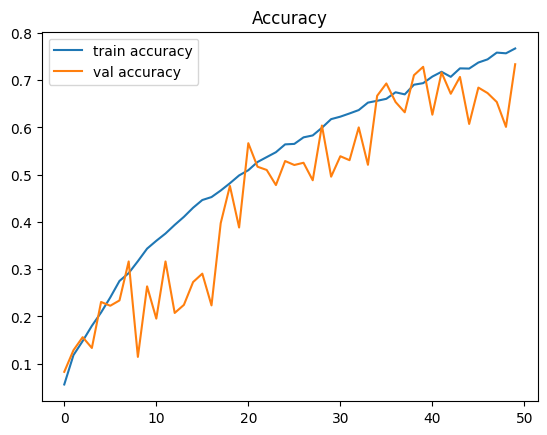

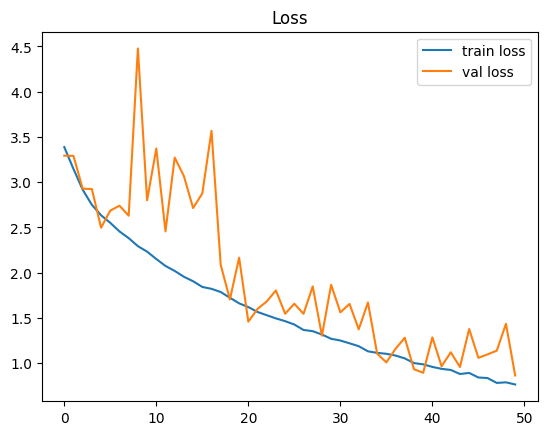

In [13]:
print(f"Deeper training time: {baseline_train_time:.2f} seconds")
# Accuracy
plt.plot(deeper_history.history['accuracy'], label='train accuracy')
plt.plot(deeper_history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(deeper_history.history['loss'], label='train loss')
plt.plot(deeper_history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [14]:
# Get predictions (probabilities)
y_pred_probs = deeper_model_sgd.predict(test_ds)
# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)
# Get true labels from the dataset
# Since shuffle=False, these will match the order of predictions
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_ds.class_names))

56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 214ms/step

Classification Report:
                       precision    recall  f1-score   support

               Bangus       0.29      0.44      0.35        34
        Big Head Carp       0.97      0.70      0.81        43
   Black Spotted Barb       0.89      0.60      0.72        40
              Catfish       0.63      0.85      0.73        62
       Climbing Perch       0.88      0.47      0.61        30
 Fourfinger Threadfin       0.80      0.63      0.71        38
       Freshwater Eel       0.69      0.67      0.68        55
       Glass Perchlet       0.88      0.79      0.84        77
                 Goby       0.81      0.71      0.76       124
            Gold Fish       0.93      1.00      0.96        41
              Gourami       0.98      0.87      0.92        63
           Grass Carp       0.99      0.81      0.89       238
 Green Spotted Puffer       0.91      0.95      0.93        22
          Indian Carp       0.72      0.98      0.8

# Transfer Learning

In [6]:
img_height = 224
img_width = 224
batch_size = 16

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=True,
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=False,
    seed=123
)

num_classes = len(train_ds.class_names)
class_names = train_ds.class_names

Found 8809 files belonging to 31 classes.


I0000 00:00:1778041488.935692    5470 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 2751 files belonging to 31 classes.


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

In [8]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [9]:
from sklearn.utils.class_weight import compute_class_weight

all_labels = np.concatenate([y.numpy() for x, y in train_ds])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)

class_weights_dict = dict(enumerate(class_weights))

In [10]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

In [11]:
for layer in base_model.layers:
    layer.trainable = False

In [12]:
from tensorflow.keras import layers, Model

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
# x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)
# x = layers.Dropout(0.5)(x)

output = layers.Dense(num_classes, activation='softmax')(x)

model_tl = Model(inputs=base_model.input, outputs=output)

In [13]:
model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight = class_weights_dict
)

Epoch 1/10


I0000 00:00:1778041538.408281    5583 service.cc:153] XLA service 0x7a69ac05d660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778041538.408382    5583 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778041538.740472    5583 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778041542.995356    5583 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778041543.112891    5583 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10411__.128
I0000 00:00:1778041570.656649    5583 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


548/551 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4710 - loss: 1.9628

I0000 00:00:1778041598.913318    5583 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10411__.128


551/551 ━━━━━━━━━━━━━━━━━━━━ 130s 159ms/step - accuracy: 0.6295 - loss: 1.3358 - val_accuracy: 0.7746 - val_loss: 0.7600
Epoch 2/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.7991 - loss: 0.6716 - val_accuracy: 0.8510 - val_loss: 0.5230
Epoch 3/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.8378 - loss: 0.5379 - val_accuracy: 0.8728 - val_loss: 0.4405
Epoch 4/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.8567 - loss: 0.4489 - val_accuracy: 0.8844 - val_loss: 0.4073
Epoch 5/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.8746 - loss: 0.3946 - val_accuracy: 0.8891 - val_loss: 0.3718
Epoch 6/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.8805 - loss: 0.3663 - val_accuracy: 0.8662 - val_loss: 0.4501
Epoch 7/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 33s 59ms/step - accuracy: 0.8944 - loss: 0.3210 - val_accuracy: 0.8917 - val_loss: 0.3436
Epoch 8/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 35s 62ms/step - accuracy: 0.8992 - loss: 0.3097 - val_accur

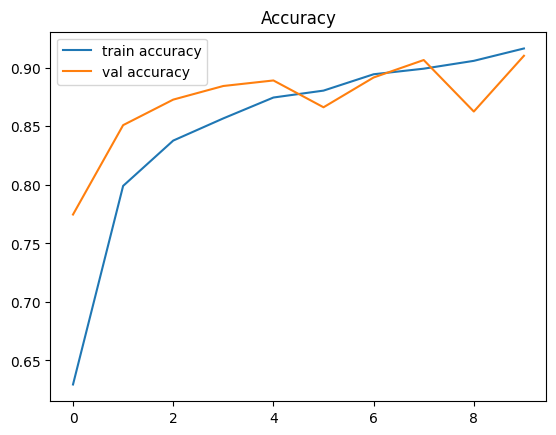

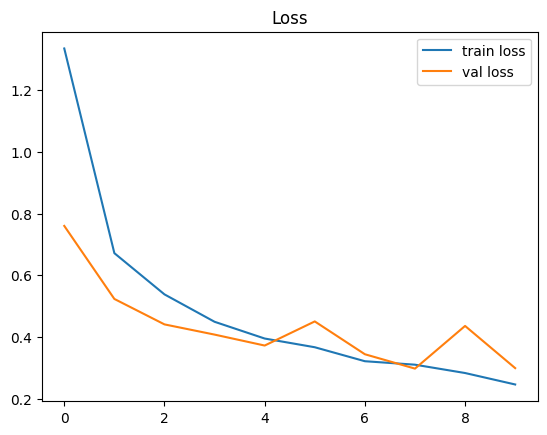

In [15]:
# Accuracy
plt.plot(history_tl.history['accuracy'], label='train accuracy')
plt.plot(history_tl.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history_tl.history['loss'], label='train loss')
plt.plot(history_tl.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [16]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 1761 files belonging to 31 classes.


# Fine Tuning

In [17]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [18]:
model_tl.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
ft_history = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight = class_weights_dict
)

Epoch 1/10


I0000 00:00:1778042141.804152    5583 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_54719__.204


549/551 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7328 - loss: 0.8950

I0000 00:00:1778042201.913846    5585 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_54719__.204


551/551 ━━━━━━━━━━━━━━━━━━━━ 134s 144ms/step - accuracy: 0.7748 - loss: 0.7268 - val_accuracy: 0.9153 - val_loss: 0.2667
Epoch 2/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 35s 62ms/step - accuracy: 0.8487 - loss: 0.4515 - val_accuracy: 0.9157 - val_loss: 0.2666
Epoch 3/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 35s 63ms/step - accuracy: 0.8776 - loss: 0.3587 - val_accuracy: 0.9128 - val_loss: 0.2696
Epoch 4/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - accuracy: 0.8830 - loss: 0.3380 - val_accuracy: 0.9131 - val_loss: 0.2688
Epoch 5/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 35s 63ms/step - accuracy: 0.9056 - loss: 0.2748 - val_accuracy: 0.9197 - val_loss: 0.2520
Epoch 6/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.9056 - loss: 0.2696 - val_accuracy: 0.9306 - val_loss: 0.2276
Epoch 7/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 37s 66ms/step - accuracy: 0.9161 - loss: 0.2417 - val_accuracy: 0.9357 - val_loss: 0.2170
Epoch 8/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 36s 64ms/step - accuracy: 0.9227 - loss: 0.2222 - val_accur

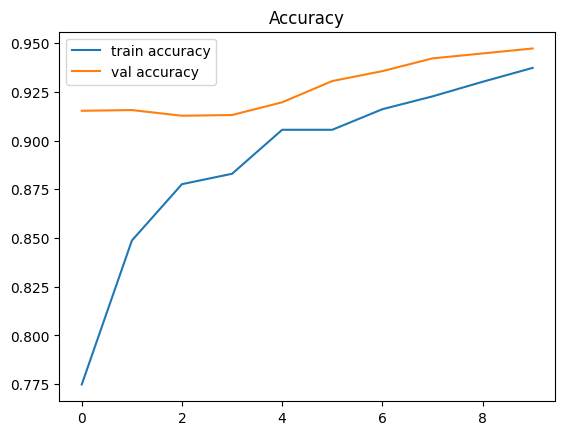

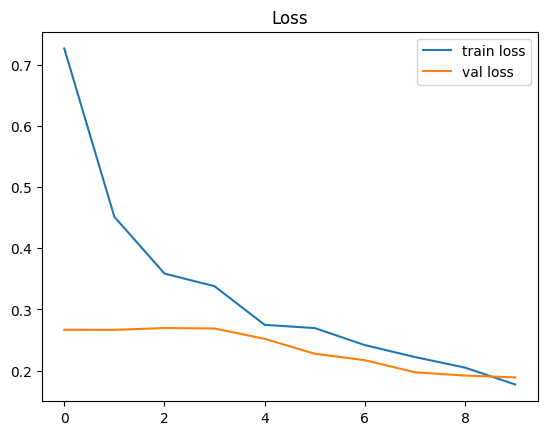

In [20]:
# Accuracy
plt.plot(ft_history.history['accuracy'], label='train accuracy')
plt.plot(ft_history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(ft_history.history['loss'], label='train loss')
plt.plot(ft_history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [23]:
test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y)
)

In [25]:
# Get predictions (probabilities)
y_pred_probs = model_tl.predict(test_ds)
# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)
# Get true labels from the dataset
# Since shuffle=False, these will match the order of predictions
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step

Classification Report:
                       precision    recall  f1-score   support

               Bangus       0.82      0.91      0.86        34
        Big Head Carp       0.90      0.84      0.87        43
   Black Spotted Barb       0.95      0.93      0.94        40
              Catfish       0.92      0.90      0.91        62
       Climbing Perch       0.96      0.80      0.87        30
 Fourfinger Threadfin       0.93      0.97      0.95        38
       Freshwater Eel       0.96      0.98      0.97        55
       Glass Perchlet       0.96      0.92      0.94        77
                 Goby       0.94      0.94      0.94       124
            Gold Fish       1.00      1.00      1.00        41
              Gourami       1.00      0.97      0.98        63
           Grass Carp       0.98      0.90      0.94       238
 Green Spotted Puffer       1.00      1.00      1.00        22
          Indian Carp       0.87      1.00      0.93 